In [1]:
import pandas as pd
from matplotlib.pyplot import xlabel

from config import ROOT
from poc.data.bronze.dataset import EntsoeMarketPriceDataset
from poc.data.bronze.metadata import BronzeBaseDatasetMetadata
from poc.data.bronze.schema import MarketPriceSchema

### LOAD MARKET DATA (DAY AHEAD PRICES FOR POLAND, NOT IMPORTANT NOW)

In [2]:
ROOT

PosixPath('/home/maciek/Projects/sopt')

In [3]:
dam_prices_path = ROOT / 'assets' / 'input' / 'dam_prices.parquet'

if not dam_prices_path.exists():
    start = pd.Timestamp("2016-01-02", tz="UTC")
    end   = pd.Timestamp("2026-01-01", tz="UTC")

    # load the meta-data (from *.yaml file; pydantic-validated)
    market_price_metadata = BronzeBaseDatasetMetadata.from_yaml(
        str(ROOT / "poc/assets/datasets/entsoe_dam_prices.yaml"),
        schema=MarketPriceSchema
    )

    market_price_dataset = EntsoeMarketPriceDataset(
        metadata=market_price_metadata,
        start=start,
        end=end,
        api_key="b25938c6-f2d3-4eda-aef2-8d71580afdcc",
    )

    dam_prices = market_price_dataset.fetch()

    dam_prices.to_parquet(ROOT / 'assets' / 'input' / 'dam_prices.parquet')

else:
    dam_prices = pd.read_parquet(dam_prices_path)



In [4]:
dam_prices.head()

,snapshot,issue_time,valid_time,data_source,data_type,market,price,currency,energy_unit,exchange_rate_to_pln
24,2026-04-04 22:52:47.678950+00:00,2016-01-02 11:00:00+00:00,2016-01-03 00:00:00+00:00,ENTSOE,OBSERVATION,DAM,19.41,EUR,MWH,1.0
25,2026-04-04 22:52:47.678950+00:00,2016-01-02 11:00:00+00:00,2016-01-03 01:00:00+00:00,ENTSOE,OBSERVATION,DAM,18.64,EUR,MWH,1.0
26,2026-04-04 22:52:47.678950+00:00,2016-01-02 11:00:00+00:00,2016-01-03 02:00:00+00:00,ENTSOE,OBSERVATION,DAM,19.41,EUR,MWH,1.0
27,2026-04-04 22:52:47.678950+00:00,2016-01-02 11:00:00+00:00,2016-01-03 03:00:00+00:00,ENTSOE,OBSERVATION,DAM,19.22,EUR,MWH,1.0
28,2026-04-04 22:52:47.678950+00:00,2016-01-02 11:00:00+00:00,2016-01-03 04:00:00+00:00,ENTSOE,OBSERVATION,DAM,19.46,EUR,MWH,1.0


### LOAD STORAGE PARAMETERS

In [5]:
from src.preprocess.load import load_storage_static_params

ssp = load_storage_static_params(ROOT / 'assets' / 'input' / 'storage_static_params.yaml')

### PLAY WITH ENVIRONMENT

In [6]:
max_days = int(len(dam_prices) / 24)
max_days

3545

In [13]:
from src.rl.environment import BatteryEnvironment

env = BatteryEnvironment(
    storage_static_params=ssp,
    energy_prices=dam_prices['price'],
    dt=1.0,
    n_hours=24,
    max_days=max_days,
)

##### One step is computed in 29 ms (this is what took me so long...)

In [14]:
import numpy as np
from src.rl.spaces import Action

# get observation for day n=0
observation = env.reset()

# call action function
transition_result = env.step(action=Action(lambda_param=np.ones(24)))

# observation for the next day is:
next_observation = transition_result.observation

# reward for the day n=0 is:
reward = transition_result.reward

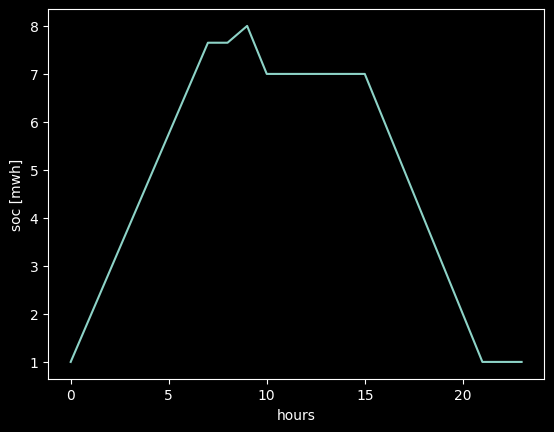

In [15]:
import matplotlib.pyplot as plt

plt.plot(transition_result.info['opt_results'].soc)
plt.xlabel('hours')
plt.ylabel('soc [mwh]')
plt.show()
